In [ ]:
!pip install -q tensorflow scikit-learn pandas matplotlib joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
from google.colab import files

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [ ]:
uploaded = files.upload() 
csv_filename = list(uploaded.keys())[0]
print("Loaded:", csv_filename)

Saving 0000.csv to 0000 (1).csv
Loaded: 0000 (1).csv


In [ ]:
df = pd.read_csv(csv_filename)
if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])
df = df.select_dtypes(include=[np.number]).copy()
print("Using features:", df.columns.tolist())
n_samples, n_features = df.shape
print("Data shape:", df.shape)

Using features: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES']
Data shape: (32399, 11)


In [ ]:
df = df.interpolate().fillna(method='bfill').fillna(method='ffill')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)  

/tmp/ipython-input-2844094563.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate().fillna(method='bfill').fillna(method='ffill')


In [ ]:
def create_windows(X, seq_len=128, step=1):
    n_samples, n_features = X.shape
    windows = []
    starts = []
    for start in range(0, n_samples - seq_len + 1, step):
        windows.append(X[start:start+seq_len])
        starts.append(start)
    return np.stack(windows), np.array(starts)

SEQ_LEN = 128  
STEP = 1
X_windows, window_starts = create_windows(X_scaled, seq_len=SEQ_LEN, step=STEP)
print("Windows shape:", X_windows.shape)  

Windows shape: (32272, 128, 11)


In [ ]:
train_windows, val_windows = train_test_split(X_windows, test_size=0.12, random_state=42)
print("Train:", train_windows.shape, "Val:", val_windows.shape)

Train: (28399, 128, 11) Val: (3873, 128, 11)


In [ ]:
# Transformer Autoencoder model
def transformer_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    # Multi-Head Self-Attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
    attn = layers.Add()([attn, x])
    attn = layers.LayerNormalization()(attn)
    # Feed-forward
    ff = layers.Dense(ff_dim, activation='relu')(attn)
    ff = layers.Dense(x.shape[-1])(ff)
    ff = layers.Add()([ff, attn])
    out = layers.LayerNormalization()(ff)
    return out

tf.keras.backend.clear_session()
input_shape = (SEQ_LEN, n_features)
inputs = layers.Input(shape=input_shape)

# Positional encoding (learned)
pos_emb = layers.Embedding(input_dim=SEQ_LEN, output_dim=n_features)
positions = tf.range(start=0, limit=SEQ_LEN, delta=1)
pos_encoding = pos_emb(positions)[None, ...] 
x = inputs + pos_encoding  # broadcast addition

# Encoder: stack of transformer blocks
x = layers.Dense(n_features)(x)
x = transformer_block(x, head_size=16, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_block(x, head_size=16, num_heads=4, ff_dim=128, dropout=0.1)
x = layers.Conv1D(filters=64, kernel_size=3, strides=2, padding='same', activation='relu')(x)  
x_shape_after_conv = tf.keras.backend.int_shape(x)

x_flat = layers.Flatten()(x)
latent_dim = 128
encoded = layers.Dense(latent_dim, activation='relu')(x_flat)

# Decoder
x = layers.Dense(x_shape_after_conv[1] * x_shape_after_conv[2], activation='relu')(encoded)
x = layers.Reshape((x_shape_after_conv[1], x_shape_after_conv[2]))(x)
x = layers.UpSampling1D(size=2)(x)  
x = transformer_block(x, head_size=16, num_heads=4, ff_dim=128, dropout=0.1)
x = transformer_block(x, head_size=16, num_heads=4, ff_dim=128, dropout=0.1)

decoded = layers.TimeDistributed(layers.Dense(n_features))(x)

autoencoder = models.Model(inputs, decoded, name="transformer_autoencoder")
autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
autoencoder.summary()

Model: "transformer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 11)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 11)   │        132 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 11)   │      3,019 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 11)   │          0 │ multi_head_atten… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 11)   │         22 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 128)  │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 11)   │      1,419 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 11)   │          0 │ dense_2[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 11)   │         22 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 11)   │      3,019 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 11)   │          0 │ multi_head_atten… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 11)   │         22 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 128)  │      1,536 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128, 11)   │      1,419 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128, 11)   │          0 │ dense_4[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 11)   │         22 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │      2,176 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,134,803 (4.33 MB)

 Trainable params: 1,134,803 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 60
BATCH_SIZE = 128
es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    train_windows, train_windows,
    validation_data=(val_windows, val_windows),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=2
)


Epoch 1/60
222/222 - 74s - 332ms/step - loss: 0.9235 - val_loss: 0.8675
Epoch 2/60
222/222 - 6s - 28ms/step - loss: 0.8216 - val_loss: 0.8091
Epoch 3/60
222/222 - 6s - 28ms/step - loss: 0.7681 - val_loss: 0.7670
Epoch 4/60
222/222 - 6s - 28ms/step - loss: 0.7322 - val_loss: 0.7266
Epoch 5/60
222/222 - 6s - 28ms/step - loss: 0.7090 - val_loss: 0.7104
Epoch 6/60
222/222 - 6s - 27ms/step - loss: 0.6969 - val_loss: 0.6985
Epoch 7/60
222/222 - 6s - 28ms/step - loss: 0.6863 - val_loss: 0.6891
Epoch 8/60
222/222 - 6s - 27ms/step - loss: 0.6796 - val_loss: 0.6844
Epoch 9/60
222/222 - 6s - 28ms/step - loss: 0.6745 - val_loss: 0.6812
Epoch 10/60
222/222 - 6s - 27ms/step - loss: 0.6690 - val_loss: 0.6759
Epoch 11/60
222/222 - 6s - 28ms/step - loss: 0.6672 - val_loss: 0.6763
Epoch 12/60
222/222 - 6s - 27ms/step - loss: 0.6673 - val_loss: 0.6763
Epoch 13/60
222/222 - 6s - 28ms/step - loss: 0.6633 - val_loss: 0.6728
Epoch 14/60
222/222 - 6s - 27ms/step - loss: 0.6621 - val_loss: 0.6716
Epoch 15/60
2

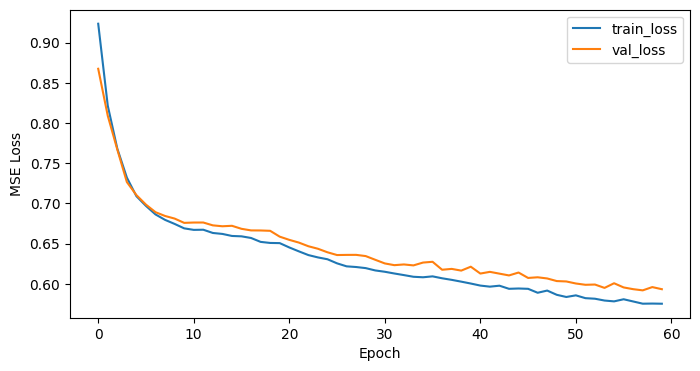

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.legend(); plt.show()

In [ ]:
reconstructions = autoencoder.predict(X_windows)
mse_per_window = np.mean(np.square(reconstructions - X_windows), axis=(1,2))

# thresholding (percentile or mean+k*std)
threshold_pct = np.percentile(mse_per_window, 98) 
threshold_stat = mse_per_window.mean() + 3 * mse_per_window.std()
print("MSE mean:", mse_per_window.mean(), "std:", mse_per_window.std())
print("Threshold (98th pct):", threshold_pct)
print("Threshold (mean + 3*std):", threshold_stat)
threshold = threshold_pct

1009/1009 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step
MSE mean: 0.5733951793087544 std: 0.8095047406003181
Threshold (98th pct): 3.8288561784994477
Threshold (mean + 3*std): 3.0019094011097085


In [ ]:
anomaly_mask_windows = mse_per_window > threshold
print("Anomalous windows:", anomaly_mask_windows.sum(), " / ", len(anomaly_mask_windows))

n_samples = X_scaled.shape[0]
sample_anomaly = np.zeros(n_samples, dtype=bool)
for i, is_anom in enumerate(anomaly_mask_windows):
    if is_anom:
        s = window_starts[i]
        sample_anomaly[s:s+SEQ_LEN] = True

pct_anom = sample_anomaly.sum() / n_samples * 100
print(f"Percent of samples flagged anomalous: {pct_anom:.3f}%")

Anomalous windows: 646  /  32272
Percent of samples flagged anomalous: 4.111%


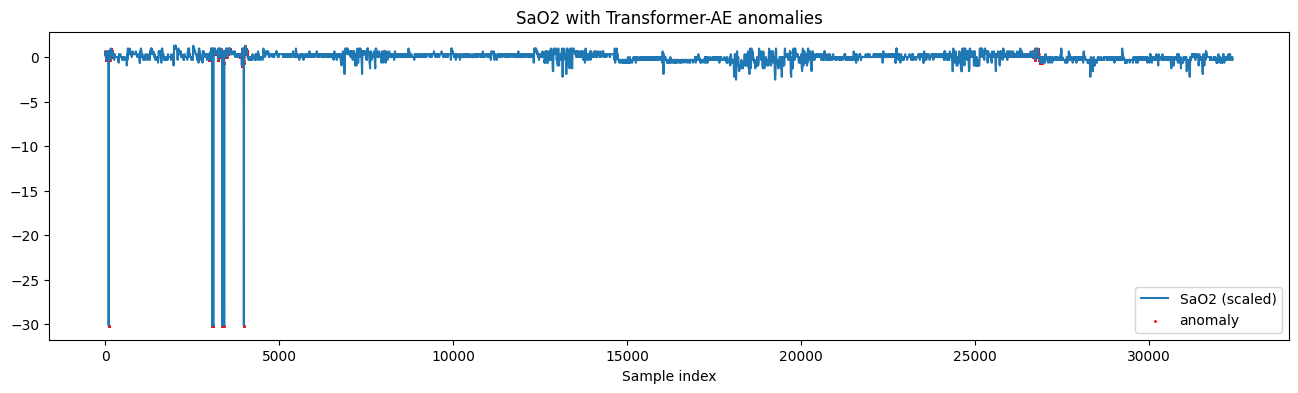

In [ ]:
feature_idx = 0
feature_name = df.columns[feature_idx]
time = np.arange(n_samples)

plt.figure(figsize=(16,4))
plt.plot(time, X_scaled[:, feature_idx], label=f"{feature_name} (scaled)")
anom_idxs = np.where(sample_anomaly)[0]
plt.scatter(anom_idxs, X_scaled[anom_idxs, feature_idx], color='red', s=1, label='anomaly')
plt.xlabel("Sample index"); plt.legend(); plt.title(f"{feature_name} with Transformer-AE anomalies"); plt.show()

In [ ]:
top_k = 10
top_idx = np.argsort(mse_per_window)[-top_k:][::-1]
print("Top anomalous windows (index, start_sample, mse):")
for rank, idx in enumerate(top_idx, 1):
    start_sample = window_starts[idx]
    print(f"{rank}. window_idx={idx}, start_sample={start_sample}, mse={mse_per_window[idx]:.6f}")

Top anomalous windows (index, start_sample, mse):
1. window_idx=26707, start_sample=26707, mse=8.016839
2. window_idx=26713, start_sample=26713, mse=7.964247
3. window_idx=26709, start_sample=26709, mse=7.962362
4. window_idx=26703, start_sample=26703, mse=7.953545
5. window_idx=26705, start_sample=26705, mse=7.949994
6. window_idx=26711, start_sample=26711, mse=7.904724
7. window_idx=26701, start_sample=26701, mse=7.902277
8. window_idx=26695, start_sample=26695, mse=7.897655
9. window_idx=26699, start_sample=26699, mse=7.837814
10. window_idx=26715, start_sample=26715, mse=7.797503


In [ ]:
autoencoder.save("transformer_autoencoder_model.keras") 
joblib.dump(scaler, "transAE_scaler.save")
print("Saved model 'transformer_autoencoder_model.keras' and scaler 'transAE_scaler.save'")

files.download("transformer_autoencoder_model.keras")
files.download("transAE_scaler.save")

Saved model 'transformer_autoencoder_model.keras' and scaler 'transAE_scaler.save'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>